In [5]:
import pandas as pd 

df = pd.read_csv('data/features_property_type.csv')

df_labeled = df[df['property_type'].notnull()]

df_unlabeled = df[df['property_type'].isnull()]

print('Number of STATIC: ', len(df[df['property_type'] == 'static']))
num_static_ids = len(df[(df['property_type'] == 'static') & (df['property_label'].str.contains(' ID'))])
num_static = len(df[df['property_type'] == 'static'])
print('Number of static properties that are IDs: ', num_static_ids, f'({num_static_ids / num_static * 100:.2f}%)')
print()

print('Number of REGULAR: ', len(df[df['property_type'] == 'regular']))
print()

print('Number of IRREGULAR: ', len(df[df['property_type'] == 'irregular']))
num_irregular_ids = len(df[(df['property_type'] == 'irregular') & (df['property_label'].str.contains(' ID'))])
print('Number of irregular properties that are IDs: ', num_irregular_ids, f'({num_irregular_ids / len(df[df["property_type"] == "irregular"]) * 100:.2f}%)')
print()

print('Number of unlabeled properties:', len(df_unlabeled))
print('Number of unlabeled properties that are IDs:', len(df_unlabeled[df_unlabeled['property_label'].str.contains(' ID')]))
print()
df_unlabeled_ids = df_unlabeled[df_unlabeled['property_label'].str.contains(' ID')]
print('Number of unlabeled properties that are not IDs:', len(df_unlabeled) - len(df_unlabeled_ids))
print()


Number of STATIC:  2778
Number of static properties that are IDs:  2215 (79.73%)

Number of REGULAR:  69

Number of IRREGULAR:  962
Number of irregular properties that are IDs:  322 (33.47%)

Number of unlabeled properties: 8704
Number of unlabeled properties that are IDs: 5847

Number of unlabeled properties that are not IDs: 2857



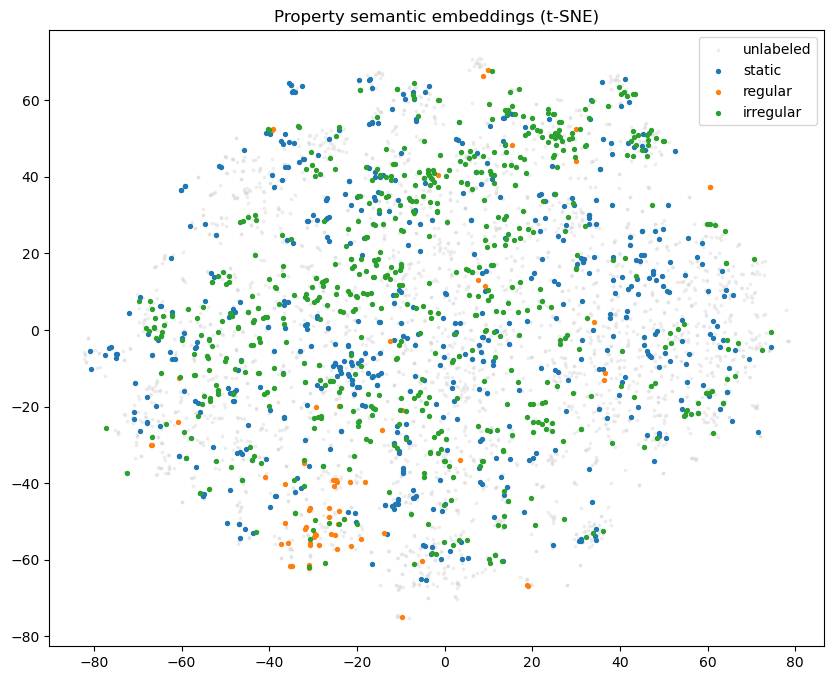

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import json
import matplotlib.pyplot as plt

df_embeddings = pd.read_csv('data/property_embeddings.csv')

df_embeddings = df_embeddings[~df_embeddings['property_label'].str.contains(' ID')].copy()
df_embeddings['embedding'] = df_embeddings['embedding'].apply(json.loads)
df_embeddings_labeled_props = df_embeddings[df_embeddings['property_type'].notnull()].copy()

X = np.vstack(df_embeddings['embedding'].values)
# X is a matrix of shape (N_samples, N_dimensions)
# reduce to 2 dimesnions for plotting
reducer = TSNE(n_components=2, perplexity=30, random_state=42)
projected_embs = reducer.fit_transform(X)

color_map = {'static': 'tab:blue', 'regular': 'tab:orange', 'irregular': 'tab:green'}
df_embeddings['color'] = df_embeddings['property_type'].map(color_map).fillna('lightgrey')

plt.figure(figsize=(10, 8))

mask = df_embeddings['property_type'].isna()
plt.scatter(projected_embs[mask, 0], projected_embs[mask, 1], c='lightgrey', s=3, alpha=0.3, label='unlabeled')
for ptype, color in color_map.items():
    m = df_embeddings['property_type'] == ptype
    plt.scatter(projected_embs[m, 0], projected_embs[m, 1], c=color, s=8, label=ptype)
plt.legend()
plt.title("Property semantic embeddings (t-SNE)")
plt.show()



## Nearest neighbors

In [42]:
df_nearest_neighbors = pd.read_csv('data/property_nearest_neighbors.csv')

df_nearest_neighbors = df_nearest_neighbors[(~df_nearest_neighbors['property_label'].str.contains(' ID')) & (df_nearest_neighbors['property_type'].notnull())].copy()
df_nearest_neighbors['nearest_property_ids'] = df_nearest_neighbors['nearest_property_ids'].apply(json.loads)
df_nearest_neighbors['nearest_property_types'] = df_nearest_neighbors['nearest_property_types'].apply(json.loads)
df_nearest_neighbors['nearest_property_labels'] = df_nearest_neighbors['nearest_property_labels'].apply(json.loads)
df_nearest_neighbors['nearest_similarities'] = df_nearest_neighbors['nearest_similarities'].apply(json.loads)

df_nearest_neighbors['nearest_sim'] = df_nearest_neighbors['nearest_similarities'].apply(lambda x: max([v for v in x if int(v) != 1]) if len(x) > 0 else None)
df_nearest_neighbors['nearest_sim_idx'] = df_nearest_neighbors['nearest_similarities'].apply(lambda x: x.index(max([v for v in x if int(v) != 1])) if len(x) > 0 else None)
df_nearest_neighbors['nearest_property_id'] = df_nearest_neighbors.apply(lambda row: row['nearest_property_ids'][row['nearest_sim_idx']] if row['nearest_sim_idx'] is not None else None, axis=1)
df_nearest_neighbors['nearest_property_type'] = df_nearest_neighbors.apply(lambda row: row['nearest_property_types'][row['nearest_sim_idx']] if row['nearest_sim_idx'] is not None else None, axis=1)
df_nearest_neighbors['nearest_property_label'] = df_nearest_neighbors.apply(lambda row: row['nearest_property_labels'][row['nearest_sim_idx']] if row['nearest_sim_idx'] is not None else None, axis=1)

display(df_nearest_neighbors[['property_label', 'property_type', 'nearest_sim','nearest_property_id', 'nearest_property_type', 'nearest_property_label', 'nearest_similarities', 'nearest_property_labels']].head(10))


,property_label,property_type,nearest_sim,nearest_property_id,nearest_property_type,nearest_property_label,nearest_similarities,nearest_property_labels
11,minor planet group,irregular,0.593130,5736,static,Minor Planet Center body ID,"[1.0000000000000009, 0.5931296683307485, 0.565...","[minor planet group, Minor Planet Center body ..."
22,point group,static,0.400665,693,static,cleavage,"[1.0000000000000009, 0.40066546541529674, 0.32...","[point group, cleavage, ionic radius, key col]"
25,mother house,irregular,0.608347,12476,irregular,filial church,"[1.0000000000000013, 0.6083470169530985, 0.467...","[mother house, filial church, religion or worl..."
30,cleavage,static,0.400665,589,static,point group,"[1.0000000000000007, 0.40066546541529674, 0.33...","[cleavage, point group, melting point, Mohs' h..."
40,excluding,static,0.478457,4330,irregular,contains,"[1.0000000000000004, 0.4784567728140989, 0.476...","[excluding, contains, not found in, criterion ..."
41,asteroid taxonomy,static,0.598654,215,irregular,spectral class,"[1.0000000000000016, 0.5986538153623422, 0.548...","[asteroid taxonomy, spectral class, items clas..."
42,flattening,irregular,0.371281,2043,static,length,"[1.0000000000000004, 0.3712811915132419, 0.367...","[flattening, length, angular diameter, thickness]"
46,group cardinality,static,0.529348,2820,static,cardinality of this set,"[1.0000000000000009, 0.5293478009284815, 0.389...","[group cardinality, cardinality of this set, c..."
48,supercharger,static,0.522790,1211,static,fuel system,"[1.0000000000000013, 0.5227895527045042, 0.468...","[supercharger, fuel system, source of energy, ..."
52,coordinates of the point of view,static,0.708024,7108,static,location of the point of view,"[1.0000000000000013, 0.7080236295466755, 0.702...","[coordinates of the point of view, location of..."


In [46]:
df = pd.read_csv('data/features_property_type.csv')

print(df[(df['property_type'] == 'static') & (~df['property_label'].str.contains(' ID'))][['property_id', 'property_label', 'property_type']].head(30))



     property_id                                     property_label  \
22           589                                        point group   
30           693                                           cleavage   
40          1011                                          excluding   
41          1016                                  asteroid taxonomy   
46          1164                                  group cardinality   
48          1210                                       supercharger   
52          1259                   coordinates of the point of view   
62          1458                                        color index   
114         2501                                            results   
118         2744                                          PASE name   
135         3199                       charity number (Isle of Man)   
139         3268                              PORT organization URL   
155         3713                 category for value not in Wikidata   
156   

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

files = {
    # "property_labels_with_deleted": ['property_id', 'property_label'],
    "properties_alias_desc_update_freq_numeric_id": ['property_id', 'property_label', 'property_data_type', 'aliases', 'property_description', 'frequency_update', 'frequency_update_label', 'has_characteristic_num_id'],
}

db_config = {
    "host": "10.130.31.22",
    "port": 5433,
    "database": "wikidata_changes_new",
    "user": "postgres",
    "password": "postgres"
}

for file_name, columns in files.items():
    csv_file_path = f'data/{file_name}.csv'
    df = pd.read_csv(csv_file_path, usecols=columns)

    engine = create_engine(f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['database']}")

    df.to_sql(file_name,
            con=engine,
            index=False,
            if_exists='replace')
